In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/creditcard.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [ ]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [ ]:
df["Class"].value_counts()
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

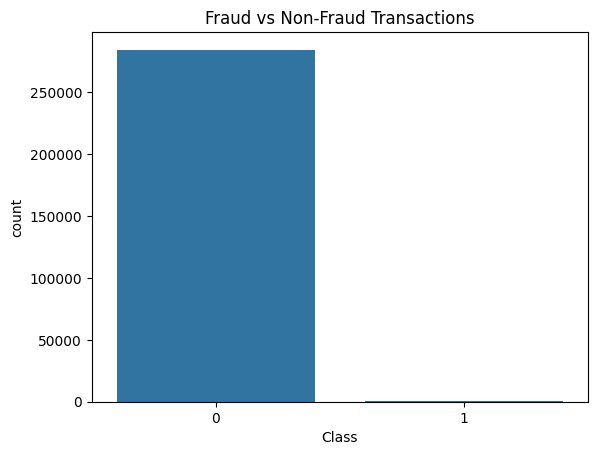

(284807, 30)
(284807,)
(227845, 30)
(56962, 30)
(454902, 30)
Class
0    227451
1    227451
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Class", data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

X = df.drop("Class", axis=1)
y = df["Class"]

print(X.shape)
print(y.shape)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train["Amount"] = scaler.fit_transform(
    X_train[["Amount"]]
)

X_test["Amount"] = scaler.transform(
    X_test[["Amount"]]
)

X_train["Time"] = scaler.fit_transform(
    X_train[["Time"]]
)

X_test["Time"] = scaler.transform(
    X_test[["Time"]]
)

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

print(X_train_resampled.shape)
print(y_train_resampled.value_counts())

processed_train = X_train_resampled.copy()
processed_train["Class"] = y_train_resampled

processed_train.to_csv(
    "../data/processed/train_processed.csv",
    index=False
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_resampled, y_train_resampled)

y_pred = rf.predict(X_test)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(
    "ROC-AUC:",
    roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

[[56849    15]
 [   16    82]]
ROC-AUC: 0.9731024901519414


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.61      0.87      0.71        98

    accuracy                           1.00     56962
   macro avg       0.80      0.93      0.86     56962
weighted avg       1.00      1.00      1.00     56962

[[56809    55]
 [   13    85]]
ROC-AUC: 0.9768807494860635


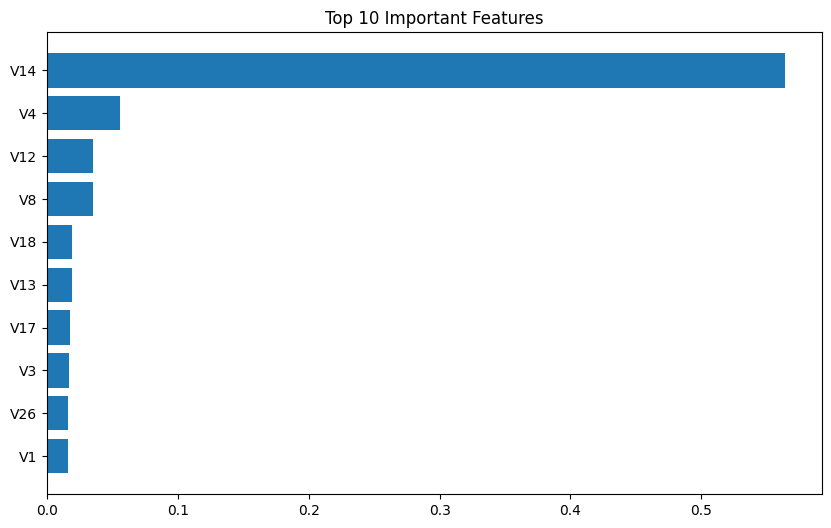

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train_resampled,
    y_train_resampled
)

y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(classification_report(
    y_test,
    y_pred_xgb
))

print(confusion_matrix(
    y_test,
    y_pred_xgb
))

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        y_prob_xgb
    )
)

import matplotlib.pyplot as plt

importance = xgb_model.feature_importances_

indices = importance.argsort()[-10:]

plt.figure(figsize=(10,6))

plt.barh(
    X_train.columns[indices],
    importance[indices]
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

In [ ]:
import joblib

joblib.dump(
    xgb_model,
    "../models/fraud_detection_model.pkl"
)

import os

os.path.exists(
    "../models/fraud_detection_model.pkl"
)

True

In [ ]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

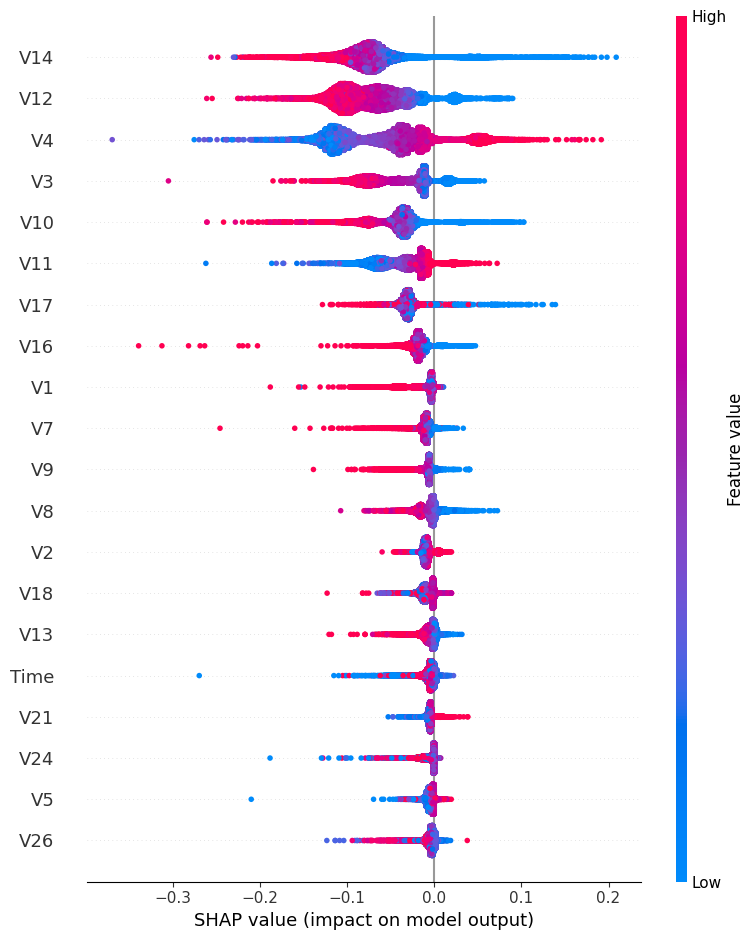

In [ ]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test
)

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": np.abs(
        shap_values[:, :, 1]   # Fraud class
    ).mean(axis=0)
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance.head(10))

   Feature  Importance
14     V14    0.079087
12     V12    0.073851
4       V4    0.067517
3       V3    0.045596
10     V10    0.044585
11     V11    0.036636
17     V17    0.031329
16     V16    0.018857
1       V1    0.011388
7       V7    0.010075


In [ ]:
top_features = feature_importance.head(10)

print(top_features)

   Feature  Importance
14     V14    0.079087
12     V12    0.073851
4       V4    0.067517
3       V3    0.045596
10     V10    0.044585
11     V11    0.036636
17     V17    0.031329
16     V16    0.018857
1       V1    0.011388
7       V7    0.010075


In [ ]:
import joblib

joblib.dump(
    rf,
    "../models/random_forest_model.pkl"
)

['../models/random_forest_model.pkl']

In [ ]:
loaded_model = joblib.load(
    "../models/random_forest_model.pkl"
)

print("Model Loaded Successfully")

Model Loaded Successfully


In [1]:
import os

print(os.getcwd())

c:\Users\Diya\OneDrive\Desktop\ML PROJECTS\Fraud-Detection-System\notebooks


In [2]:
import os

print(os.path.exists("../models/random_forest_model.pkl"))

True
